# Is this measuring anything real?

`scstability` reports a number between 0 and 1 for each of your clusters. This
notebook is the evidence that the number means something. Every figure and
table below is executed; nothing here is asserted.

Four questions, in increasing order of how badly a wrong implementation would
fail them:

1. Does it recover structure whose answer is **known independently of the
   expression matrix**?
2. Does it distinguish real structure from a **matched null** with no clusters?
3. Does it measure **set recovery**, which is what Hennig's Jaccard is for, or
   merely local homogeneity?
4. Does it add anything over **seed stability**, which is ~30× cheaper?

Question 4 is the one that could sink the package, so it gets the most space.

In [1]:
import os
import pathlib
import subprocess
import sys
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

import scstability as scs

warnings.simplefilter("ignore")
sc.settings.verbosity = 0
pd.set_option("display.width", 200)

DATA = pathlib.Path(os.environ.get("SCSTABILITY_DATA", "data"))
RESOLUTIONS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
N_BOOT = 20

# A single-hue sequential ramp for magnitude, plus the reserved status colours.
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
GOOD, WARN, BAD = "#0ca30c", "#fab219", "#d03b3b"
plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": GRID,
        "axes.labelcolor": "#52514e",
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.titlecolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)
print("scstability", scs.__version__)

scstability 0.1.0.dev0


## A note on what counts as ground truth

Most single-cell "ground truth" is not ground truth. A cell-type column in a
published object was almost always produced by **clustering that same
expression matrix** and then naming the clusters. Validating a clustering
method against it is partly circular.

Only one of the datasets below escapes that. `sc_10x_5cl` (Tian et al. 2019)
mixes five human cell lines and sequences them together; every cell is
assigned to its line by **SNP genotype**. Genetics, not expression.

In [2]:
path = DATA / "sc_10x_5cl_ground_truth.h5ad"
if not path.exists():
    subprocess.run(
        [sys.executable, "benchmarks/fetch_ground_truth.py", "5cl", "--out", str(DATA)],
        check=True,
    )

full = ad.read_h5ad(path)
truth = full.obs["ground_truth"].astype(str).to_numpy()

adata = ad.AnnData(np.zeros((full.n_obs, 1), dtype=np.float32))
adata.obsm["X_pca"] = np.ascontiguousarray(full.obsm["X_pca"], dtype=np.float32)

print(f"{full.n_obs:,} genotype-verified singlets")
pd.Series(truth).value_counts().rename("cells").to_frame()

3,822 genotype-verified singlets


,cells
A549,1237
H838,841
H2228,744
HCC827,571
H1975,429


### What the data looks like

Five cell lines, labelled by DNA. `scstability` never sees these labels; it
sees fifty PCA coordinates.

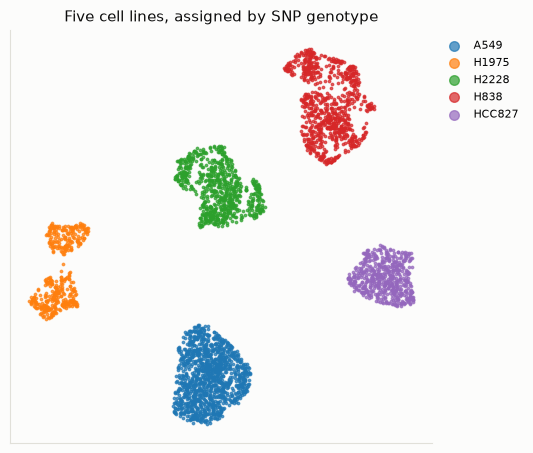

In [3]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=0)
sc.tl.umap(adata, random_state=0)
adata.obs["genotype"] = pd.Categorical(truth)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
for name, group in pd.DataFrame(
    {"x": adata.obsm["X_umap"][:, 0], "y": adata.obsm["X_umap"][:, 1], "line": truth}
).groupby("line"):
    ax.scatter(group.x, group.y, s=3, alpha=0.7, label=name)
ax.legend(
    markerscale=4,
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
)
ax.set(xticks=[], yticks=[], title="Five cell lines, assigned by SNP genotype")
plt.tight_layout()
plt.show()

## Question 1. Does it recover the true K?

There are five cell lines. A resolution producing five clusters should be
maximally stable, and everything finer should collapse, because a finer
partition has to cut *within* a cell line.

In [4]:
result = scs.stability_sweep(
    adata, RESOLUTIONS, n_boot=N_BOOT, random_state=0, progress=False
)
result.summary().round(3)

,resolution,n_clusters,min_cluster_stability,median_cluster_stability,frac_cells_stable
0,0.1,5,0.980,1.000,1.000
1,0.2,6,0.880,0.995,1.000
2,0.4,9,0.187,0.928,0.961
3,0.6,11,0.478,0.957,0.956
4,0.8,12,0.717,0.975,0.942
5,1.0,12,0.723,0.956,0.910
6,1.5,18,0.429,0.861,0.861


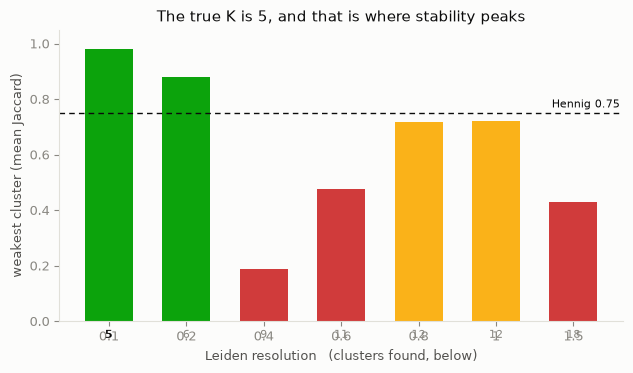

In [5]:
summary = result.summary()
fig, ax = plt.subplots(figsize=(6.4, 3.8))
colours = [
    GOOD if v >= 0.75 else WARN if v >= 0.6 else BAD
    for v in summary["min_cluster_stability"]
]
ax.bar(range(len(summary)), summary["min_cluster_stability"], color=colours, width=0.62)
ax.axhline(0.75, color=INK, lw=1, ls=(0, (4, 3)))
ax.text(len(summary) - 0.4, 0.77, "Hennig 0.75", fontsize=8, color=INK, ha="right")
pairs = zip(summary["resolution"], summary["n_clusters"], strict=True)
for i, (_res, n) in enumerate(pairs):
    ax.text(
        i,
        -0.06,
        f"{n}",
        ha="center",
        fontsize=8,
        color=INK if n == 5 else MUTED,
        fontweight="bold" if n == 5 else "normal",
    )
ax.set_xticks(range(len(summary)))
ax.set_xticklabels([f"{r:g}" for r in summary["resolution"]])
ax.set(
    ylim=(0, 1.05),
    xlabel="Leiden resolution   (clusters found, below)",
    ylabel="weakest cluster (mean Jaccard)",
    title="The true K is 5, and that is where stability peaks",
)
plt.tight_layout()
plt.show()

The five-cluster partition is essentially perfect. Everything finer falls off a
cliff, because there is nothing real left to cut.

**But note what it does not do.** `recommend()` returns 0.2, giving six
clusters, not five: one cell line is split into two halves that are *both*
reproducible. Stability cannot identify the true K: a reproducible over-split
is still reproducible. That limitation is real and is stated in the README.

In [6]:
print("recommend() ->", result.recommend())

recommend() -> 0.2


## Question 2. Can it tell real structure from none?

The control is a single multivariate Gaussian matched to the data's mean and
covariance: the same shape and elongation, but **exactly one mode**, so any
cluster found in it is an artefact of the algorithm.

A permutation null is the obvious choice and it is **wrong**, which is worth
showing rather than asserting. Shuffling each coordinate independently
preserves that coordinate's marginal *exactly*, multimodality included.

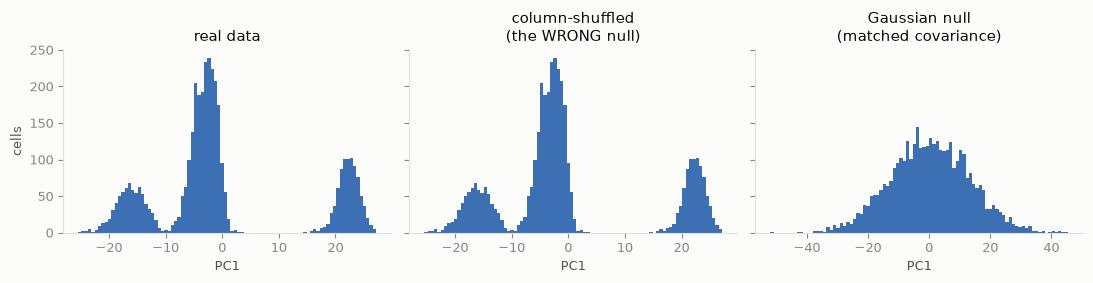

total variance   real 741.0   shuffled 741.0   gaussian 739.1


In [7]:
rng = np.random.default_rng(0)
X = np.asarray(adata.obsm["X_pca"], dtype=np.float64)

shuffled = X.copy()
for j in range(shuffled.shape[1]):
    rng.shuffle(shuffled[:, j])

gaussian = rng.multivariate_normal(
    X.mean(axis=0), np.cov(X, rowvar=False), size=X.shape[0], method="svd"
)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9), sharey=True)
panels = [
    ("real data", X),
    ("column-shuffled\n(the WRONG null)", shuffled),
    ("Gaussian null\n(matched covariance)", gaussian),
]
for ax, (name, A) in zip(axes, panels, strict=True):
    ax.hist(A[:, 0], bins=90, color="#3d6fb4", edgecolor="none")
    ax.set(title=name, xlabel="PC1")
axes[0].set_ylabel("cells")
plt.tight_layout()
plt.show()

print(
    f"total variance   real {X.var(axis=0).sum():.1f}   "
    f"shuffled {shuffled.var(axis=0).sum():.1f}   "
    f"gaussian {gaussian.var(axis=0).sum():.1f}"
)

The middle panel is the point. Shuffling preserves PC1's marginal **exactly**:
the same clumps, the same variance. A product of multimodal marginals is a
*lattice* of clumps in fifty dimensions: more strongly clustered than the real
data, not less. It was never a null.

The Gaussian null keeps the shape and has one mode.

In [8]:
def sweep_of(matrix):
    obj = ad.AnnData(np.zeros((matrix.shape[0], 1), dtype=np.float32))
    obj.obsm["X_pca"] = np.ascontiguousarray(matrix, dtype=np.float32)
    return scs.stability_sweep(
        obj, RESOLUTIONS, n_boot=N_BOOT, random_state=0, progress=False
    )


null = sweep_of(gaussian)
merged = summary.merge(null.summary(), on="n_clusters", suffixes=("_real", "_null"))
merged[
    ["n_clusters", "min_cluster_stability_real", "min_cluster_stability_null"]
].round(3)

,n_clusters,min_cluster_stability_real,min_cluster_stability_null
0,6,0.880,0.328
1,9,0.187,0.257
2,11,0.478,0.316


Compared **at matched cluster counts**, which is the only fair comparison: a
coarse partition is trivially more reproducible than a fine one, so the
headline numbers are not comparable across different cluster counts.

Real data beats the null at every matched count. Note also the null's coarsest
resolutions, which collapse to a single cluster and score a perfect 1.0:

In [9]:
null.summary()[["resolution", "n_clusters", "min_cluster_stability"]].round(3)

,resolution,n_clusters,min_cluster_stability
0,0.1,1,1.000
1,0.2,1,0.982
2,0.4,3,0.424
3,0.6,6,0.328
4,0.8,9,0.257
5,1.0,11,0.316
6,1.5,16,0.204


**A single cluster containing every cell scores 1.0.** Structureless data earns
the best possible number for the worst possible reason. This defect was found
by running exactly this control, and `recommend()` now refuses to return such a
resolution and warns instead:

In [10]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    print("null recommend() ->", null.recommend())
for w in caught:
    print("WARNING:", w.message)

null recommend() -> 0.4


## Question 3. Set recovery, or just local purity?

For each cluster, two external measures against the genotype labels:

* **purity**: are these cells all one line?
* **truth_jaccard**: is this cluster the *whole* line, cut the same way?
  (purity **and** completeness)

Hennig's Jaccard is a set measure, so it should track the second, not the
first. This dataset makes the distinction unusually stark: cell lines are so
distinct that Leiden never mixes them, so **every cluster is 100% pure at every
resolution**, because it only ever splits *within* a line.

In [11]:
def best_truth_jaccard(mask, labels):
    best = 0.0
    for value in np.unique(labels):
        member = labels == value
        union = np.logical_or(mask, member).sum()
        if union:
            best = max(best, float(np.logical_and(mask, member).sum() / union))
    return best


rows = []
for res in RESOLUTIONS:
    sc.tl.leiden(
        adata,
        resolution=res,
        key_added="_ref",
        flavor="igraph",
        n_iterations=2,
        directed=False,
        random_state=0,
    )
    labels = adata.obs["_ref"].astype(str).to_numpy()
    block = result.cluster_stability
    for _, row in block[block.resolution == res].iterrows():
        mask = labels == str(int(row["cluster"]))
        if not mask.any():
            continue
        counts = pd.Series(truth[mask]).value_counts()
        rows.append(
            dict(
                resolution=res,
                n_cells=int(mask.sum()),
                stability=float(row["jaccard_mean"]),
                truth_jaccard=best_truth_jaccard(mask, truth),
                purity=counts.iloc[0] / mask.sum(),
            )
        )
clusters = pd.DataFrame(rows).dropna()
print(f"{len(clusters)} clusters pooled across {len(RESOLUTIONS)} resolutions")

73 clusters pooled across 7 resolutions


In [12]:
print(
    f"purity across all {len(clusters)} clusters: "
    f"min {clusters.purity.min():.3f}, max {clusters.purity.max():.3f}, "
    f"sd {clusters.purity.std():.4f}"
)
print(
    f"agreement with a real cell line ranges "
    f"{clusters.truth_jaccard.min():.2f} to {clusters.truth_jaccard.max():.2f}"
)

purity across all 73 clusters: min 1.000, max 1.000, sd 0.0000
agreement with a real cell line ranges 0.11 to 1.00


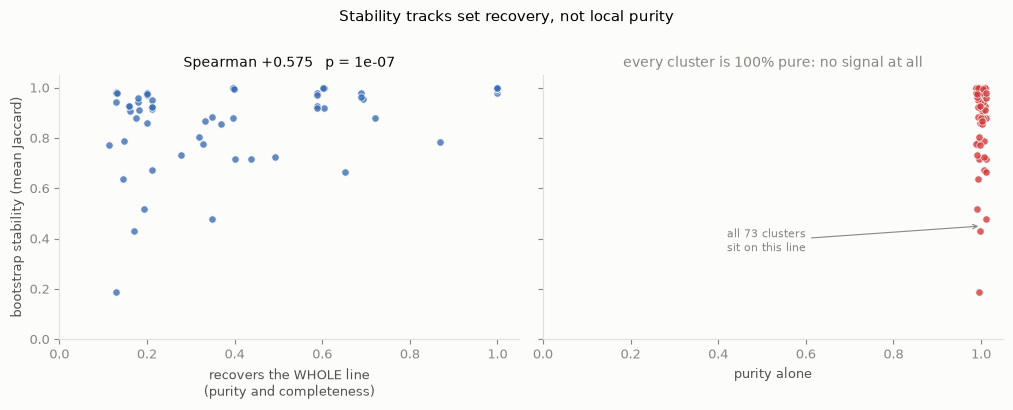

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0), sharey=True)

rho, p = stats.spearmanr(clusters["truth_jaccard"], clusters["stability"])
axes[0].scatter(
    clusters["truth_jaccard"],
    clusters["stability"],
    s=28,
    alpha=0.8,
    color="#3d6fb4",
    edgecolor="#fcfcfb",
    linewidth=0.6,
)
axes[0].set(
    xlabel="recovers the WHOLE line\n(purity and completeness)",
    ylabel="bootstrap stability (mean Jaccard)",
    xlim=(0, 1.05),
    ylim=(0, 1.05),
)
axes[0].set_title(f"Spearman {rho:+.3f}   p = {p:.1g}", fontsize=10, color=INK)

jitter = np.random.default_rng(0).uniform(-0.012, 0.012, len(clusters))
axes[1].scatter(
    clusters["purity"] + jitter,
    clusters["stability"],
    s=28,
    alpha=0.8,
    color=BAD,
    edgecolor="#fcfcfb",
    linewidth=0.6,
)
axes[1].set(xlabel="purity alone", xlim=(0, 1.05))
axes[1].set_title(
    "every cluster is 100% pure: no signal at all", fontsize=10, color=MUTED
)
axes[1].annotate(
    "all 73 clusters\nsit on this line",
    xy=(1.0, 0.45),
    xytext=(0.42, 0.35),
    fontsize=8,
    color=MUTED,
    arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 0.8},
)
fig.suptitle("Stability tracks set recovery, not local purity", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

**That contrast is the finding, and it is starker than a weak correlation.**

Purity calls all 73 clusters perfect: it is exactly 1.0 for every one, so it
has *zero* discriminating power on this data. Yet those same clusters recover a
real cell line anywhere from 0.13 to 1.00, and stability separates them at
Spearman +0.58.

The mechanism is visible in the resolution sweep above: past resolution 0.2,
Leiden starts cutting *within* cell lines. Each half is still 100% pure, and every
cell in it really is an A549 cell, but the place the split falls moves on every
resample. Purity cannot see that. A set measure can, which is what Hennig's
Jaccard is for, and why neighbourhood-purity QC does not substitute for it.

## Question 4. Does it add anything over seed stability?

This is the question that could sink the package. `ClustAssessPy` and `scICE`
measure **seed stability**: rerun the same clustering on the same graph with a
different seed. That is roughly 30× cheaper than resampling. If it gives the
same answer, users should use it instead and we should say so.

Both arms below use **identical clustering**: same graph, same Leiden
flavour, iterations and resolutions. The only difference is what is perturbed:
the seed, or the cells.

In [14]:
try:
    from ClustAssessPy import element_consistency

    HAVE_CA = True
except ImportError:
    HAVE_CA = False
    print("ClustAssessPy not installed -- install it to run section 4")

if HAVE_CA:

    def seed_ecs(resolution, n_seeds=20):
        partitions = []
        for seed in range(n_seeds):
            sc.tl.leiden(
                adata,
                resolution=resolution,
                key_added="_s",
                flavor="igraph",
                n_iterations=2,
                directed=False,
                random_state=seed,
            )
            partitions.append(adata.obs["_s"].astype(int).to_numpy())
        return np.asarray(element_consistency(partitions), dtype=float)

    seed_rows = []
    for res in RESOLUTIONS:
        ecs = seed_ecs(res)
        sc.tl.leiden(
            adata,
            resolution=res,
            key_added="_ref",
            flavor="igraph",
            n_iterations=2,
            directed=False,
            random_state=0,
        )
        labels = adata.obs["_ref"].astype(str).to_numpy()
        block = result.cluster_stability
        for _, row in block[block.resolution == res].iterrows():
            mask = labels == str(int(row["cluster"]))
            if not mask.any():
                continue
            seed_rows.append(
                dict(
                    resolution=res,
                    n_cells=int(mask.sum()),
                    seed_ecs=float(np.mean(ecs[mask])),
                    sampling=float(row["jaccard_mean"]),
                    truth=best_truth_jaccard(mask, truth),
                )
            )
    both = pd.DataFrame(seed_rows).dropna()
    print(f"{len(both)} clusters measured both ways")

73 clusters measured both ways


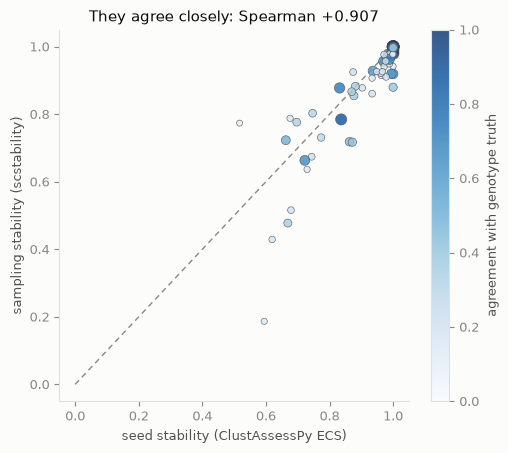

shared variance r^2 = 0.82


In [15]:
if HAVE_CA:
    rho, p = stats.spearmanr(both["seed_ecs"], both["sampling"])
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    sizes = 12 + 60 * both["truth"]
    dots = ax.scatter(
        both["seed_ecs"],
        both["sampling"],
        s=sizes,
        alpha=0.8,
        c=both["truth"],
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolor="#52514e",
        linewidth=0.5,
    )
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=(0, (4, 3)), zorder=0)
    plt.colorbar(dots, ax=ax, label="agreement with genotype truth")
    ax.set(
        xlabel="seed stability (ClustAssessPy ECS)",
        ylabel="sampling stability (scstability)",
        title=f"They agree closely: Spearman {rho:+.3f}",
    )
    plt.tight_layout()
    plt.show()
    print(f"shared variance r^2 = {rho**2:.2f}")

**They agree closely, and this does not flatter the package.** On cluster
ranking alone, reseeding would give you largely the same answer far more
cheaply. That is scICE's argument and on this evidence it has force.

But look at the horizontal axis. ECS is bounded above and **saturates**: once
the algorithm finds a partition reliably on a fixed graph, reseeding cannot
disturb it, whether or not the partition is real.

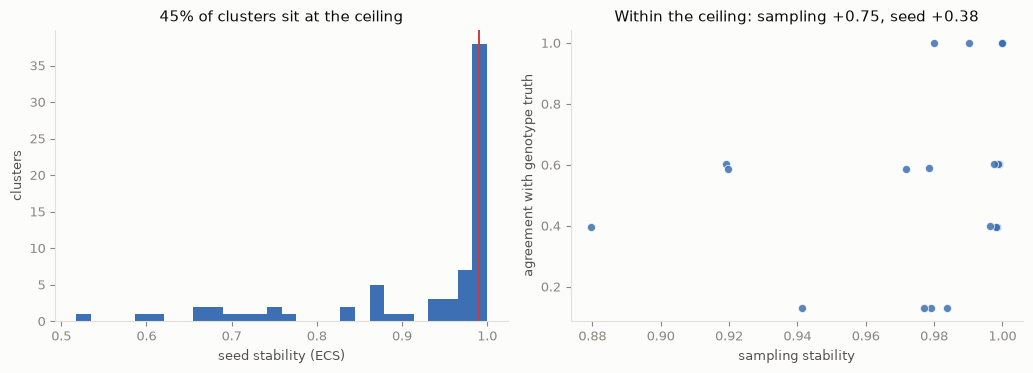

inside the saturated band, true quality still ranges 0.13 to 1.00


In [16]:
if HAVE_CA:
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.8))
    axes[0].hist(both["seed_ecs"], bins=28, color="#3d6fb4", edgecolor="none")
    axes[0].axvline(0.99, color=BAD, lw=1.4)
    frac = (both["seed_ecs"] >= 0.99).mean()
    axes[0].set(
        xlabel="seed stability (ECS)",
        ylabel="clusters",
        title=f"{frac:.0%} of clusters sit at the ceiling",
    )

    sat = both[both["seed_ecs"] >= 0.99]
    axes[1].scatter(
        sat["sampling"],
        sat["truth"],
        s=34,
        alpha=0.85,
        color="#3d6fb4",
        edgecolor="#fcfcfb",
        linewidth=0.6,
    )
    rs, ps = stats.spearmanr(sat["sampling"], sat["truth"])
    re_, _ = stats.spearmanr(sat["seed_ecs"], sat["truth"])
    axes[1].set(
        xlabel="sampling stability",
        ylabel="agreement with genotype truth",
        title=f"Within the ceiling: sampling {rs:+.2f}, seed {re_:+.2f}",
    )
    plt.tight_layout()
    plt.show()
    print(
        f"inside the saturated band, true quality still ranges "
        f"{sat['truth'].min():.2f} to {sat['truth'].max():.2f}"
    )

Left: a large share of clusters sit at the ECS ceiling, where seed stability
has no range left. Right: inside that band their true quality still varies from
near zero to one, and **sampling stability separates them while seed stability
cannot**.

### The threshold-free version

Conditioning on ECS ≥ 0.99 is a cutoff chosen after seeing the data, so the
primary analysis uses **no threshold**: does either measure predict the truth
once the other is already known?

In [17]:
if HAVE_CA:

    def partial_spearman(x, y, z):
        rx, ry, rz = (stats.rankdata(np.asarray(v, float)) for v in (x, y, z))

        def resid(a, b):
            slope, intercept, *_ = stats.linregress(b, a)
            return a - (slope * b + intercept)

        return stats.pearsonr(resid(rx, rz), resid(ry, rz))

    def rank_r2(target, preds):
        design = np.column_stack([np.ones(len(target)), *preds])
        beta, *_ = np.linalg.lstsq(design, target, rcond=None)
        return 1 - (target - design @ beta).var() / target.var()

    ps, pps = partial_spearman(both["sampling"], both["truth"], both["seed_ecs"])
    pe, ppe = partial_spearman(both["seed_ecs"], both["truth"], both["sampling"])
    rt = stats.rankdata(both["truth"])
    r_seed = rank_r2(rt, [stats.rankdata(both["seed_ecs"])])
    r_samp = rank_r2(rt, [stats.rankdata(both["sampling"])])
    r_both = rank_r2(
        rt, [stats.rankdata(both["seed_ecs"]), stats.rankdata(both["sampling"])]
    )

    display(
        pd.DataFrame(
            {
                "partial Spearman vs truth": [
                    f"{ps:+.3f} (p={pps:.2g})",
                    f"{pe:+.3f} (p={ppe:.2g})",
                ],
                "R^2 alone": [f"{r_samp:.3f}", f"{r_seed:.3f}"],
                "R^2 it ADDS to the other": [
                    f"{r_both - r_seed:+.3f}",
                    f"{r_both - r_samp:+.3f}",
                ],
            },
            index=[
                "sampling stability (scstability)",
                "seed stability (ClustAssessPy)",
            ],
        )
    )

,partial Spearman vs truth,R^2 alone,R^2 it ADDS to the other
sampling stability (scstability),+0.277 (p=0.017),0.331,+0.056
seed stability (ClustAssessPy),+0.008 (p=0.95),0.275,+0.000


**Seed stability adds essentially nothing once sampling stability is known.
The reverse is not true.** No threshold anywhere in that calculation.

The effect is modest, a few points of R², and the **asymmetry** is the
finding, not the magnitude.

### The honest recommendation

If your clusters are clearly separated and you need a *ranking*,
`ClustAssessPy` is cheaper and will usually agree. If you need to know whether
one specific confident-looking cluster is real, reseeding cannot tell you,
because it never removes a cell.

## What this establishes, and what it does not

**Established.** Recovers the true K on genotype-labelled data; correlates with
externally verified identity; tracks set recovery rather than local purity;
separates real structure from a matched unimodal null; adds information seed
stability cannot express.

**Not established.**

* **Three datasets is not a survey.** Scale is measured separately
  ([`scaling.py`](scaling.py), up to 68,000 cells). Correctness and scale are
  different claims on different data.
* **`scICE` and `chooseR` were not run.** No number for either appears anywhere
  in this repository.
* **Stability is not validity.** A reproducible cluster can still be a doublet
  artefact or an uncorrected batch. This measures whether a boundary is an
  artefact of *which cells you sampled*, and nothing more.

Reusable scripts for every check above sit alongside this notebook in
`benchmarks/`.
`benchmarks/`.
